In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#declarying the arrays
# Time array (t) in months
t = np.array([
    1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,
    13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24
])

# Production Rate array (q) in Mscf/day
q = np.array([
    904.84, 818.73, 740.82, 670.32, 606.53, 548.81,
    496.59, 449.33, 406.57, 367.88, 332.87, 301.19,
    272.53, 246.60, 223.13, 201.90, 182.68, 165.30,
    149.57, 135.34, 122.46, 110.80, 100.26,  90.72
])


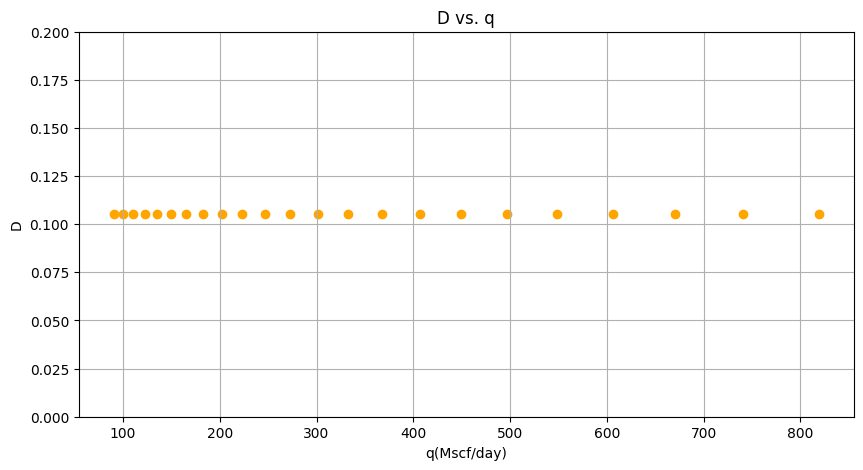

In [36]:
# determining relative decline rate 

deltaq = np.diff(q)  # q[i+1] - q[i] -> length 23
deltat = np.diff(t)  # t[i+1] - t[i]
q_nominal = q[1:]

D = -1*(deltaq/deltat)/q_nominal

#identifying the model by plotting the graph 
plt.figure(figsize=(10,5))

plt.scatter(q[1:],D, color='orange', marker='o')
plt.ylim(0,0.2)

plt.xlabel("q(Mscf/day)")
plt.ylabel("D")
plt.title("D vs. q")
plt.grid()
plt.show()


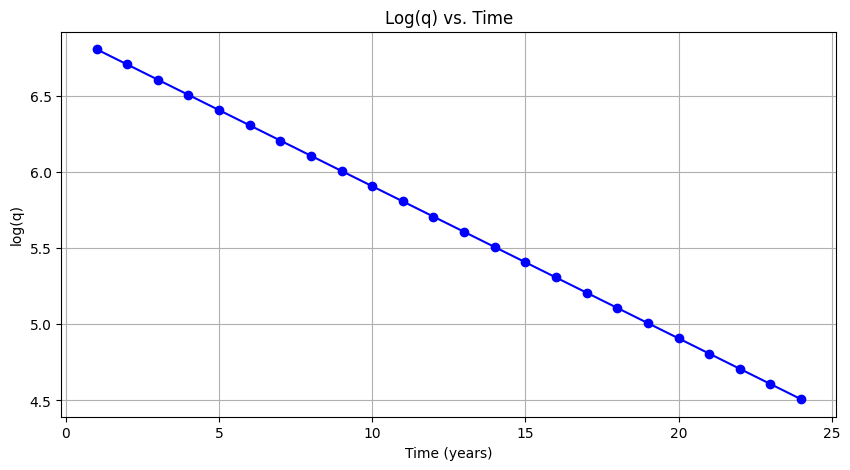

In [38]:
# Log transformation for exponential decline model analysis
log_q = np.log(q)

# Plot log(q) vs. Time to indentify the model 
plt.figure(figsize=(10,5))
plt.plot(t, log_q,'o-', color='blue')
plt.xlabel("Time (years)")
plt.ylabel("log(q)")
plt.title("Log(q) vs. Time")
plt.grid()
plt.show()


In [39]:
#finding model parameters 
b = (np.log(q[0]) - np.log(q[-1])) / (t[-1] - t[0])
qi = q[5]/np.exp(-b*t[5])

print("contonous decline rate is;")
print(b)
print("1/month")

print("initial production rate is")
print(qi)
print("Mscf/day")

contonous decline rate is;
0.09999914315261707
1/month
initial production rate is
999.9918777865593
Mscf/day


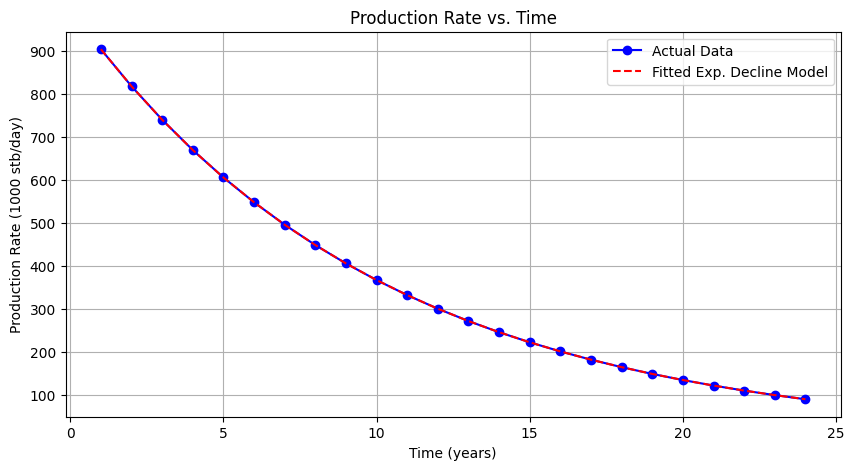

In [40]:
# Predicting q values using exponential model
q_predicted = qi * np.exp(-b * t)

# Plot Production Rate vs. Time
plt.figure(figsize=(10,5))
plt.plot(t, q, 'bo-', label="Actual Data")
plt.plot(t, q_predicted, 'r--', label="Fitted Exp. Decline Model")
plt.xlabel("Time (years)")
plt.ylabel("Production Rate (1000 stb/day)")
plt.title("Production Rate vs. Time")
plt.legend()
plt.grid()
plt.show()

Calculated Decline Rate (D): 0.1000 per month
Calculated Initial Rate (qi): 999.99 Mscf/day
Cumulative production at month 24: 276,602.88 Mscf


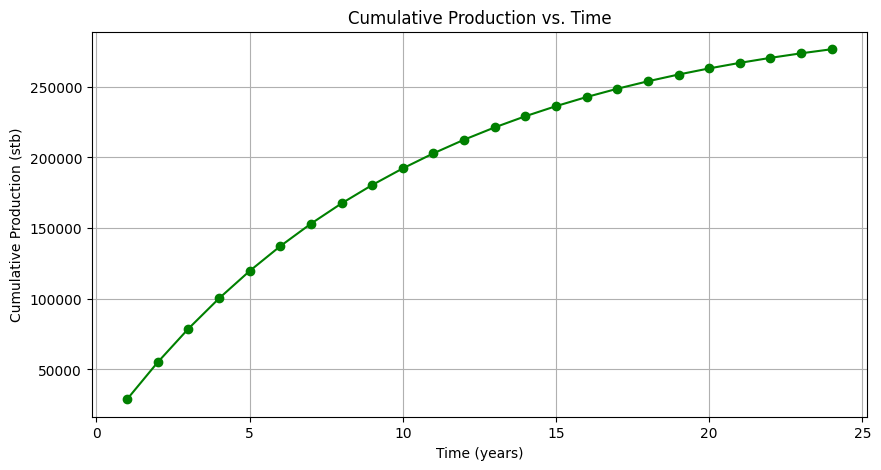

In [45]:
# Cumulative production calculations
Np =np.zeros(len(q))
for i in range(len(q)):
    Np[i] = ((qi - q[i])*30.42) / b



print(f"Calculated Decline Rate (b): {b:.4f} per month")
print(f"Calculated Initial Rate (qi): {qi:.2f} Mscf/day")
print(f"Cumulative production at month 24: {Np[-1]:,.2f} Mscf")

# Plot cumulative production vs. time
plt.figure(figsize=(10,5))
plt.plot(t, Np, 'go-', label="Cumulative Production")
plt.xlabel("Time (years)")
plt.ylabel("Cumulative Production (stb)")
plt.title("Cumulative Production vs. Time")
plt.grid()
plt.show()